In [12]:

from scipy.signal import butter, lfilter
import scipy.io
import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt
import ast

import sys
sys.path.insert(1, '..\src')
from data_processing import bandpass_filter, derivative_filter

In [2]:
from data_loader import load_raw_data

path = "../data/raw/ptb-xl-1.0.3/"
sampling_rate = 100

Y = pd.read_csv(path + "ptbxl_database.csv", index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

X = load_raw_data(Y, sampling_rate, path)

100%|██████████| 21799/21799 [09:41<00:00, 37.50it/s]


In [3]:

# def load_raw_data(df, sampling_rate, path):
#     if sampling_rate == 100:
#         data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
#     else:
#         data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
#     data = np.array([signal for signal, meta in data])
#     return data


# print("yo")

In [6]:
Y.head() 

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [7]:
missing = Y.isnull().sum()
missing_percentage = (missing / len(Y)) * 100

missing_values = pd.DataFrame(
    {
        'Missing Values': missing,
        'Percentage': missing_percentage.round(2)
    }
)
# print(missing)
# print(missing_percentage)
missing_values

,Missing Values,Percentage
patient_id,0,0.00
age,0,0.00
sex,0,0.00
height,14825,68.01
weight,12378,56.78
nurse,1473,6.76
site,17,0.08
device,0,0.00
recording_date,0,0.00
report,0,0.00


In [8]:
scp_statements = pd.read_csv(path + "scp_statements.csv")
scp_statements.rename(columns={'Unnamed: 0': 'code'}, inplace=True)
scp_statements.head()

,code,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
0,NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
1,NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
2,DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
3,LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
4,NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


In [9]:
print(Y['scp_codes'].iloc[0])
code_counts = {}
for code in scp_statements['code']: 
    code_counts[code] = 0
    
for scp_codes in Y['scp_codes']:
    for code in scp_codes:
        if scp_codes[code] > 0:
            code_counts[code] += 1
print(sum(code_counts.values()))
sorted(code_counts.items(), key=lambda x: x[1], reverse=True)[:20]
        

{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
32015


[('NORM', 9514),
 ('IMI', 2676),
 ('ASMI', 2357),
 ('LVH', 2132),
 ('NDT', 1825),
 ('LAFB', 1623),
 ('ISC_', 1272),
 ('IRBBB', 1118),
 ('PVC', 1027),
 ('1AVB', 793),
 ('IVCD', 787),
 ('ISCAL', 659),
 ('NST_', 559),
 ('CRBBB', 541),
 ('CLBBB', 536),
 ('ILMI', 478),
 ('LAO/LAE', 426),
 ('AMI', 353),
 ('ALMI', 288),
 ('PACE', 287)]

In [10]:
# def bandpass_filter (signal, lowcut, highcut, sampling_rate, order = 2):
#     nyquist = 0.5 * sampling_rate
#     low = lowcut / nyquist
#     high = highcut / nyquist
#     b, a = butter(order, [low, high], btype = "band")
#     y = lfilter(b, a, signal)
#     return y


    

In [13]:

lowcut = 0.5
highcut = 24.0
sampling_rate = 100

flattened_signal = X[0].flatten()
# print(flattened_signal.shape)

filtered_signal = bandpass_filter(flattened_signal, lowcut, highcut, sampling_rate)

In [14]:
reshaped_data = filtered_signal.reshape(1000, 12)

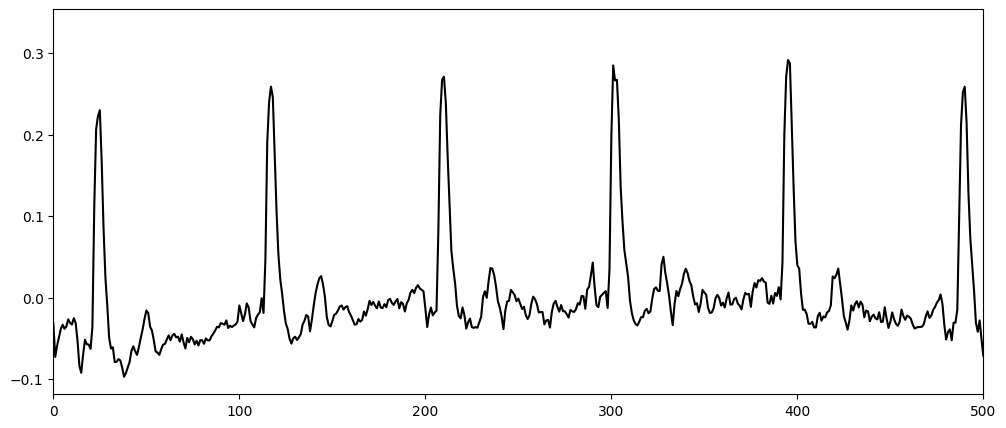

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(reshaped_data[:,0], color = "black")
plt.xlim(0, 500)
plt.show()

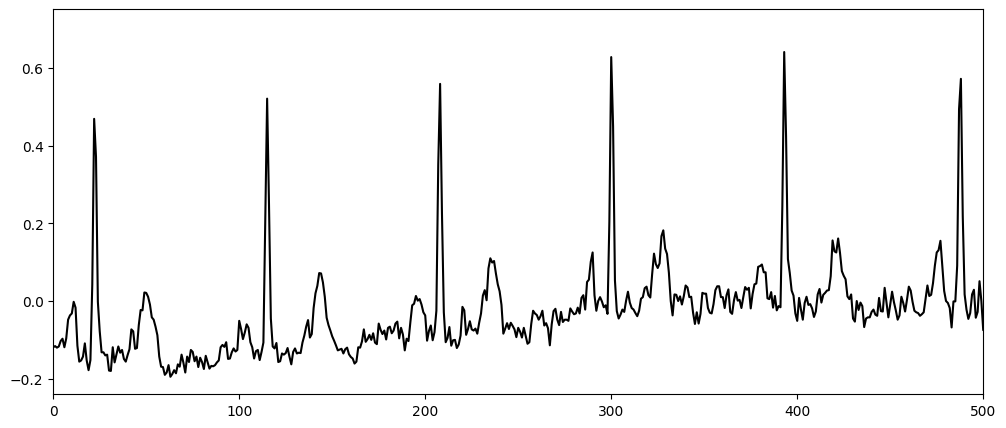

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(X[0][:,0], color = "black")
plt.xlim(0, 500)
plt.show()

In [17]:
der = derivative_filter(reshaped_data[:,0])

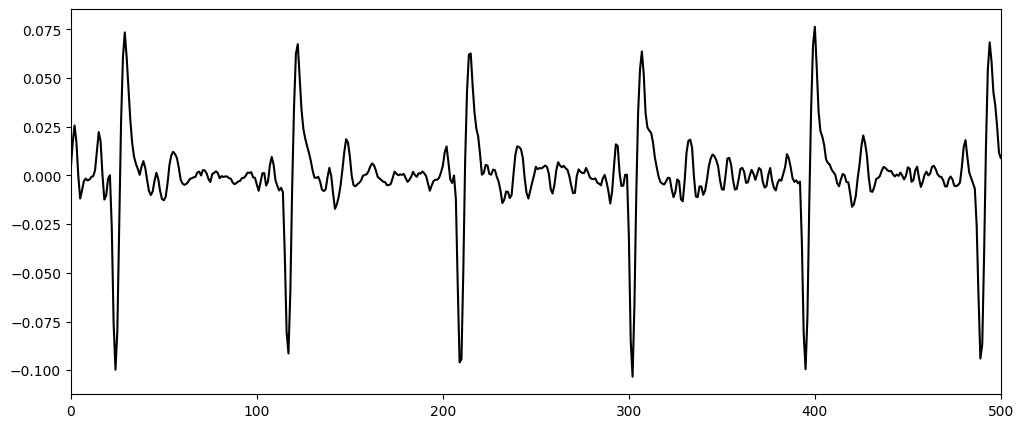

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(der, color = "black")
plt.xlim(0, 500)
plt.show()

In [19]:
squared_signal = der ** 2

In [20]:
def moving_window(signal, fs = 100, window_ms = 150):
    window_size = int((window_ms / 1000) * fs) # 15 data points 150/1000*100
    window = np.ones(window_size) / window_size
    return np.convolve(signal, window)

    

In [21]:
window_signal = moving_window(squared_signal)

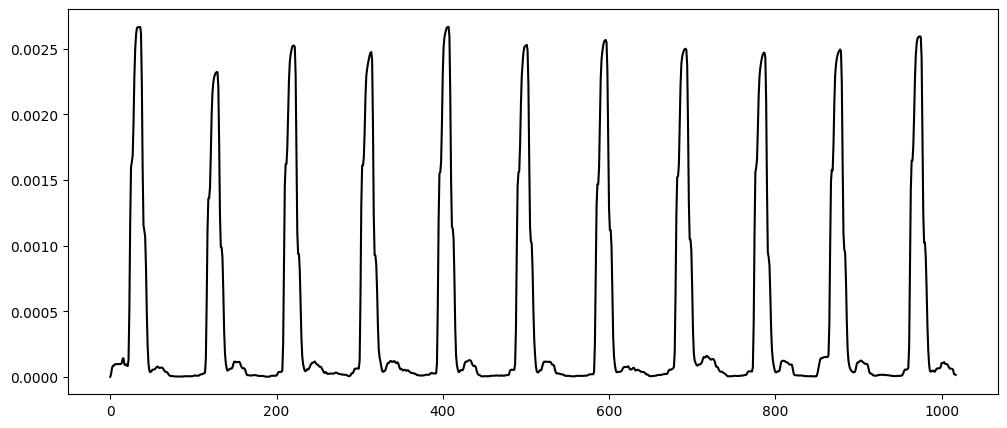

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(window_signal, color = "black")
plt.show()

In [23]:
def manual_Rpeaks(signal, fs = 100):
    threshold = np.mean((signal) + np.max(signal)) / 2
    min_distance = round(fs * 0.2)
    
    peaks = []
    length = len(signal)
    
    for i in range(1, length - 1):
        if signal[i] > signal[i-1] and signal[i] >  signal[i+1] and signal[i] > threshold and (not peaks or i - peaks[-1] >= min_distance): 
            peaks.append(i)
            
    return np.array(peaks)



In [24]:
peaks_1 = manual_Rpeaks(window_signal)

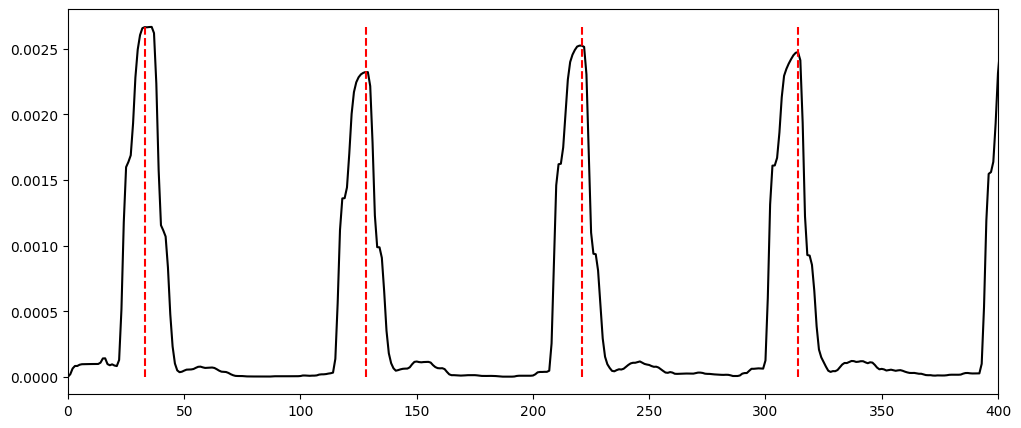

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(window_signal, color = "black")
plt.vlines(peaks_1, ymin = min(window_signal), ymax= max(window_signal), color = "red", linestyle = '--')
plt.xlim(0, 400)
plt.show()